### <p style="text-align:center;">Malware Detection - Using Machine Learning</p>

# Malware Analysis and PE File Feature Extraction

## What is Malware?
**Malware** (short for *malicious software*) refers to any software intentionally designed to cause harm, disrupt operations, steal data, gain unauthorized access, or perform other malicious actions on a system without the user's consent.

---

## Malware Analysis Techniques

To extract meaningful features from malware and understand the problem space, **malware analysis** is performed using three primary approaches:

1. **Static Analysis**  
   Features are extracted without executing the file. This includes parsing **PE file headers**, extracting metadata, section information, imports/exports, and other structural properties.

2. **Dynamic Analysis**  
   The file (malware or benign) is executed in a secure, isolated environment (e.g., sandbox), and runtime behaviors—such as API calls, network activity, file system changes, and registry modifications—are observed and logged.

3. **Hybrid Analysis**  
   Combines both static and dynamic methods to leverage structural insights and behavioral evidence for more robust detection.

> **In this notebook**, we use a dataset where features are extracted **solely via static analysis** from **PE file sections and headers**.

---

## What are PE Files?

**PE (Portable Executable)** is the native executable file format used by **Microsoft Windows** for executables (`.exe`), dynamic link libraries (`.dll`), drivers, and other system components.

- **Introduced by Microsoft** in **Windows NT 3.1 (1993)** as part of the Win32 API.
- Evolved from earlier formats like **COFF** (Common Object File Format) and **NE** (New Executable).
- Supports both **32-bit (PE32)** and **64-bit (PE32+)** architectures.

> **Why PE files?**  
> Windows remains the **most targeted operating system** by malware due to its widespread use in enterprise and consumer environments. Thus, analyzing **PE file structure** is critical for building effective malware detection models.
- <a href='https://wiki.osdev.org/PE' target='blank'>More on PE File Format 1 </a>
- <a href='https://learn.microsoft.com/en-us/windows/win32/debug/pe-format' target='blank'>More on PE File Format 2 </a>
---

## Important Considerations in PE Feature Engineering

When extracting features from PE files, several issues must be addressed:

### 1. **Zero-Variance Features**
Some fields have **constant values** across the dataset and provide **no discriminative power**.  
Example:  
- `e_magic` (the DOS signature `"MZ"`) — always the same, indicates 16-bit stub presence.  
These should be **removed** before modeling.

### 2. **Deprecated/Obsolete DOS Header Fields**
Many fields in the **DOS header** (e.g., `e_lfanew`, `e_oemid`) were designed for **backward compatibility** with early Windows/DOS systems.  
They often contain **default or near-constant values** (e.g., large blocks of zeros) and add **no predictive value**.

### 3. **Perfectly or Highly Correlated Features**
Redundant features increase model complexity and risk overfitting. Examples include:

| Feature Pair | Issue |
|-------------|-------|
| `SectionsLength` & `NumberOfSections` | Both represent the **count of sections** in the PE file — **100% correlation**. |
| Other high-correlation pairs (>90%) | Must be identified and reduced to minimize **feature redundancy**. |

>In the subsequent steps, we proceed with data cleaning, removal of redundant features, and modeling to effectively distinguish malicious files from benign ones.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

sns.set_style("darkgrid", {
    'axes.edgecolor': 'white',
    'grid.color': 'white'
})

In [9]:
data = pd.read_csv('Malware-Benign.csv')

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19611 entries, 0 to 19610
Data columns (total 79 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Hash_md5_Name                 19611 non-null  object 
 1   e_magic                       19611 non-null  int64  
 2   e_cblp                        19611 non-null  int64  
 3   e_cp                          19611 non-null  int64  
 4   e_crlc                        19611 non-null  int64  
 5   e_cparhdr                     19611 non-null  int64  
 6   e_minalloc                    19611 non-null  int64  
 7   e_maxalloc                    19611 non-null  int64  
 8   e_ss                          19611 non-null  int64  
 9   e_sp                          19611 non-null  int64  
 10  e_csum                        19611 non-null  int64  
 11  e_ip                          19611 non-null  int64  
 12  e_cs                          19611 non-null  int64  
 13  e

In [11]:
data.shape

(19611, 79)

In [12]:
data.isna().sum().sum()

np.int64(0)

In [13]:
data.drop(columns='Hash_md5_Name',inplace=True)
data.sample(3)

,e_magic,e_cblp,e_cp,e_crlc,e_cparhdr,e_minalloc,e_maxalloc,e_ss,e_sp,e_csum,...,SectionMaxChar,SectionMainChar,DirectoryEntryImport,DirectoryEntryImportSize,DirectoryEntryExport,ImageDirectoryEntryExport,ImageDirectoryEntryImport,ImageDirectoryEntryResource,ImageDirectoryEntryException,ImageDirectoryEntrySecurity
2413,23117,144,3,0,4,0,65535,0,184,0,...,3221225536,0,3,53,0,0,41980,200704,0,0
8954,23117,144,3,0,4,0,65535,0,184,0,...,3221225536,0,5,88,0,0,177376,184320,0,0
9882,23117,144,3,0,4,0,65535,0,184,0,...,1610612768,0,0,0,0,0,1926672,1941504,0,2190848


<hr />
<b>Remove duplicate rows..</b>

In [14]:
print('Before: ',len(data[data.duplicated]))
data.drop_duplicates(inplace=True)
print('After: ',len(data[data.duplicated]))

Before:  2971
After:  0


<hr />
<b>Remove the columns that have zero variance.</b>

In [8]:
features_var = data.var()
var_0 = features_var[(features_var==0)]
print(var_0)
drop_var = var_0.index.tolist()
data.drop(columns=drop_var,inplace=True)

e_magic                  0.0
SectionMaxEntropy        0.0
SectionMaxRawsize        0.0
SectionMaxVirtualsize    0.0
SectionMinPhysical       0.0
SectionMinVirtual        0.0
SectionMinPointerData    0.0
SectionMainChar          0.0
dtype: float64


<hr />

### Reason: Deprecation of DOS Header
<p style='text-align:justify;'>
The DOS Header section of PE files has been preserved only for backward compatibility with MS-DOS since Windows NT (1993). In modern Windows versions (Windows 10/11), none of its fields (such as e_magic, e_lfanew, e_cp, e_cblp, etc.) are actually used by the operating system. Therefore, these fields do not provide meaningful information for machine learning–based modeling and can be safely removed.
</p>

In [9]:
drop_dos_header=['e_cblp', 'e_cp', 'e_crlc', 'e_cparhdr', 'e_minalloc', 'e_maxalloc', 'e_ss',
'e_sp', 'e_csum', 'e_ip', 'e_cs', 'e_lfarlc', 'e_ovno', 'e_oemid',
'e_oeminfo', 'e_lfanew', 'Machine', 'Magic']
data.drop(columns=drop_dos_header,inplace=True)

<hr />
<b>Remove the columns that contain a very high proportion of zero values.</b>

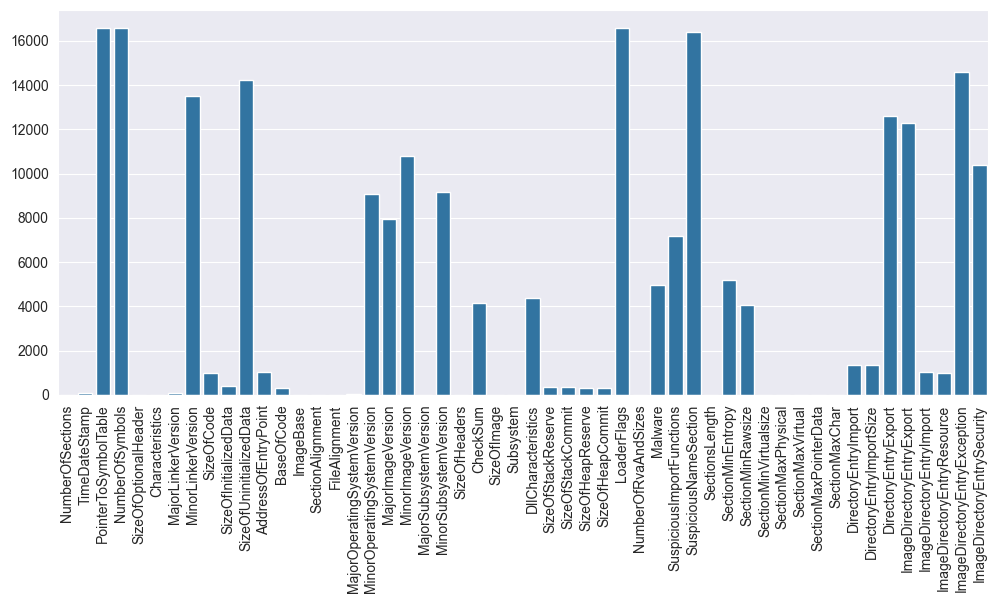

In [10]:
zero_values = {}
for cols in data.columns:
    zero_values[cols] = (data[cols]==0).sum()
plt.figure(figsize=(12,5))
sns.barplot(x=zero_values.keys() , y=zero_values.values())
plt.tick_params(axis='x', rotation=90)
plt.show()
#drop section:
drop_zero_features=[]
for keys, values in zero_values.items():
    if values >12000:
        drop_zero_features.append(keys)
data.drop(columns=drop_zero_features,inplace=True)

<hr />

### Feature Correlation Analysis and Redundancy Reduction
<P style="text-align: justify;text-justify: inter-word;"></P>
In this stage of preprocessing, highly correlated feature pairs were identified to detect redundancy within the dataset. Features exhibiting strong mutual correlation were considered to carry overlapping information. To prevent multicollinearity and enhance the model’s generalization capability, only the features with stronger correlation to the target variable (Malware) were retained for further modeling.
</P>
<P style="text-align: justify;text-justify: inter-word;">
This selection approach ensures that the retained features contribute unique and meaningful predictive power, leading to a more efficient and less noisy feature space.
</P>

<hr />
<b>Examination of features that have a correlation higher than 80% with each other:</b>

In [11]:
corr = data.corr()
mask = (corr.abs() >= 0.8) & (corr != 1.0)
high_corr = corr.where(mask).stack().reset_index()
high_corr[high_corr['level_0'] < high_corr['level_1']].sort_values(by=0,ascending=False)


,level_0,level_1,0
0,NumberOfSections,SectionsLength,0.999974
9,SectionMinRawsize,SectionMinVirtualsize,0.999528
3,MajorOperatingSystemVersion,MinorOperatingSystemVersion,0.903224
2,BaseOfCode,MinorOperatingSystemVersion,0.886408
1,AddressOfEntryPoint,SectionMaxPointerData,0.879485
6,MajorImageVersion,MinorImageVersion,0.814136


<hr />
<b>Among the highly correlated features, those with stronger correlation to the target variable were retained, and the remaining features were removed:</b>

In [12]:
features1_corr_malware ={
    'NumberOfSections':data.NumberOfSections.corr(data.Malware),
    'SectionMinRawsize':data.SectionMinRawsize.corr(data.Malware),
    'MajorOperatingSystemVersion':data.MajorOperatingSystemVersion.corr(data.Malware),
    'BaseOfCode':data.BaseOfCode.corr(data.Malware),
    'AddressOfEntryPoint':data.AddressOfEntryPoint.corr(data.Malware),
    'MajorImageVersion':data.MajorImageVersion.corr(data.Malware)
}
features2_corr_malware ={
    'SectionsLength':data.SectionsLength.corr(data.Malware),
    'SectionMinVirtualsize':data.SectionMinVirtualsize.corr(data.Malware),
    'MinorOperatingSystemVersion':data.MinorOperatingSystemVersion.corr(data.Malware),
    'MinorOperatingSystemVersion_':data.MinorOperatingSystemVersion.corr(data.Malware),
    'SectionMaxPointerData':data.SectionMaxPointerData.corr(data.Malware),
    'MinorImageVersion':data.MinorImageVersion.corr(data.Malware)
}
temp_df_corr1 = pd.DataFrame(features1_corr_malware.items(), columns=['Feature_1', 'Corr_1'])
temp_df_corr2 = pd.DataFrame(features2_corr_malware.items(), columns=['Feature_2', 'Corr_2'])
df_corr = pd.concat([temp_df_corr1, temp_df_corr2], axis=1)
df_corr

,Feature_1,Corr_1,Feature_2,Corr_2
0,NumberOfSections,0.101681,SectionsLength,0.101601
1,SectionMinRawsize,-0.066795,SectionMinVirtualsize,-0.063650
2,MajorOperatingSystemVersion,0.013794,MinorOperatingSystemVersion,0.014144
3,BaseOfCode,0.012931,MinorOperatingSystemVersion_,0.014144
4,AddressOfEntryPoint,0.049966,SectionMaxPointerData,0.053589
5,MajorImageVersion,-0.016957,MinorImageVersion,-0.020455


In [13]:
#Drop Section:
drop_high_corr = ['SectionsLength', 'SectionMinVirtualsize', 'MajorOperatingSystemVersion',
                  'BaseOfCode','AddressOfEntryPoint','MajorImageVersion']
data.drop(columns=drop_high_corr, inplace=True)


### Features Selection
<b>
In this section, by leveraging the mutual information method, we perform pre-screening and reduce the features to 15 dimensions to subsequently identify the top features for modeling using the forward feature selection method.
</b>

In [14]:
data.shape

(16642, 37)

In [15]:
#Due to imbalanced label distribution, we use StratifiedKFold for stratified data splitting.
data.Malware.value_counts(normalize=True).mul(100)

Malware
1    70.159837
0    29.840163
Name: proportion, dtype: float64

# Data Splitting

In this section, we only perform data splitting. Due to the imbalanced scale of the data, there is no need for data standardization. This is because many PE features—such as:

- `NumberOfSections`
- `SizeOfCode`
- `Entropy`
- `ImageBase`
- `Characteristics`
- `VirtualSize`
- ...

—already carry **domain-meaningful scales**.

When standardization is applied:  
It eliminates critical domain-specific information that indicates malicious behavior.

In [16]:
x=data.drop(columns='Malware')
y=data.Malware
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

### SelectKBest + Mutual_infromation_classif

In [17]:
#Feature Select - Mutual_information_classif
selector = SelectKBest(mutual_info_classif, k=15)
xtrain_select_mi = selector.fit_transform(X_train, y_train)
selector.transform(X_test)
feature_name = X_train.columns[selector.get_support()]
X_train_mi = X_train[feature_name]
X_test_mi = X_test[feature_name]
display(X_train_mi.head(1))

,TimeDateStamp,Characteristics,MajorLinkerVersion,ImageBase,MinorOperatingSystemVersion,MinorImageVersion,MajorSubsystemVersion,MinorSubsystemVersion,CheckSum,Subsystem,DllCharacteristics,SizeOfStackReserve,SectionMinEntropy,SectionMinRawsize,ImageDirectoryEntryImport
18028,1377168037,8226,11,6.442451e+09,3,3,6,3,103875,2,352,262144,2.339316,1024,99512


### Feature Selection With SequentialFeatureSelector 

In [18]:
#Feature Select - SequentialFeatureSelector 
cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = GaussianNB()
sfs = SequentialFeatureSelector(estimator=model, cv=cv)
sfs.fit(X_train_mi,y_train)
feature_name = list(X_train_mi.columns[sfs.get_support()])
X_train_sfs = X_train_mi[feature_name]
X_test_sfs = X_test_mi[feature_name]

# Compute the mean accuracy score of the model on the selected features (x_train_sfs) using stratified cross-validation
scoring = cross_val_score(model, X=X_train_sfs, y=y_train, cv=cv, scoring='accuracy').mean()
print('cross_val: ',scoring)

cross_val:  0.9452310759835403


## Final Selected Features for Modeling

| Feature                  | Description |
|--------------------------|-------------|
| `Characteristics`        | Flags indicating the file's attributes (e.g., executable, DLL). |
| `MajorLinkerVersion`     | Major version number of the linker used to create the PE file. |
| `MinorImageVersion`      | Minor version of the image, often set by developers for versioning. |
| `MajorSubsystemVersion`  | Major version of the subsystem (e.g., Windows GUI/Console) required. |
| `Subsystem`              | Specifies the subsystem (e.g., GUI, CUI) needed to run the image. |
| `DllCharacteristics`     | Flags defining DLL-specific behaviors and security attributes. |
| `SectionMinEntropy`      | Minimum entropy among sections; low values may indicate packing or obfuscation. |

In [19]:
#Predict X-test - Naive Bayes
y_pred = model.fit(X_train_sfs,y_train).predict(X_test_sfs)
print('Accuracy: ',accuracy_score(y_test, y_pred))
print('\n',classification_report(y_test, y_pred))

Accuracy:  0.9431203685159223

               precision    recall  f1-score   support

           0       0.88      0.93      0.91      1477
           1       0.97      0.95      0.96      3516

    accuracy                           0.94      4993
   macro avg       0.93      0.94      0.93      4993
weighted avg       0.94      0.94      0.94      4993



<hr />
## Modeling with Naive Bayes: 94% Test Accuracy Achieved!

Using a **Naive Bayes classifier** on the cleaned and selected PE features, we achieved a solid **94% accuracy** on the test set — a strong baseline for malware detection.

> **Your Turn to Level Up!**  
> This notebook provides a clean, reproducible pipeline. Can you push performance further?  
> Try:  
> - **Advanced models**: XGBoost, LightGBM, CatBoost, or Neural Networks  
> - **Ensemble methods**: Stacking, Voting, or Blending  
> - **Feature engineering**: Entropy-based metrics, import/export graph features  
> - **Cross-validation strategies** or **class-weighted training** for better robustness  

**Fork this notebook and beat 94%!** 🚀  
*Contributions and improvements are highly encouraged.*